# CARLA ML Safety — All Practical Exercises (Sheets 3–6)

**What this notebook covers:**
| Sheet | Exercise | Topic |
|-------|----------|-------|
| 3 | 3.4, 3.5, 3.6, 3.7 | Dataset exploration, train 3 models, evaluate, ODD gap |
| 4 | 4.5, 4.6, 4.7 | ODD coverage, test suite, per-class eval |
| 5 | 5.4, 5.5 | Temperature scaling, backdoor attack |
| 6 | 6.5, 6.6 | Grad-CAM explainability, OOD explanation |

**Quick start:**
1. Upload your CARLA dataset zip or set `DATASET_PATH` in **Cell 2**
2. Run all cells top-to-bottom
3. Models auto-download at the end — use those paths for later sheets

## ⚙️ Cell 1 — Install & imports

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

!pip install -q torch torchvision matplotlib numpy opencv-python-headless Pillow scikit-learn seaborn

import os, glob, random, shutil, copy, zipfile
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import cv2
from PIL import Image
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as tv_models
import torchvision.transforms as T
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             accuracy_score, confusion_matrix, ConfusionMatrixDisplay)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
if DEVICE == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

os.makedirs('/content/models', exist_ok=True)
os.makedirs('/content/results', exist_ok=True)
print('Directories ready.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
GPU: Tesla T4
Directories ready.


## 📁 Cell 2 — Dataset path CONFIG (edit this)

Set `DATASET_PATH` to your CARLA dataset root **or** upload a zip and set `DATASET_ZIP`.

In [2]:
# ─────────────────────────────────────────────────────────────
# DATASET PATHS — Google Drive
# ─────────────────────────────────────────────────────────────
DRIVE_ROOT     = '/content/drive/MyDrive/CARLA_DATASET'

TRAIN_IMG_DIR  = os.path.join(DRIVE_ROOT, 'train',      'rgb-front')
TRAIN_CSV      = os.path.join(DRIVE_ROOT, 'train',      'labels.csv')
TEST_IMG_DIR   = os.path.join(DRIVE_ROOT, 'test',       'rgb-front')
TEST_CSV       = os.path.join(DRIVE_ROOT, 'test',       'labels.csv')
OOD_FOG_IMG    = os.path.join(DRIVE_ROOT, 'test-fog',   'rgb-front')
OOD_FOG_CSV    = os.path.join(DRIVE_ROOT, 'test-fog',   'labels.csv')
OOD_NIGHT_IMG  = os.path.join(DRIVE_ROOT, 'test-night', 'rgb-front')
OOD_NIGHT_CSV  = os.path.join(DRIVE_ROOT, 'test-night', 'labels.csv')

# ── Exact CSV column names ──
FNAME_COL = 'frame'
TASK_COLS = {
    'pedestrian':    'has_pedestrian',
    'traffic_light': 'has_traffic_light',
    'vehicle':       'has_vehicle',
}
TASKS = list(TASK_COLS.keys())

# ── Hyperparams ──
NUM_EPOCHS  = 5
BATCH_SIZE  = 32
LR          = 1e-4
IMG_SIZE    = (224, 224)

# ── Auto-detect image filename format from actual files in rgb-front/ ──
def detect_filename_format(img_dir, sample_frame):
    """
    Given a frame number like 0 or 10, try common filename patterns
    and return the one that actually exists.
    """
    n = int(float(sample_frame))
    candidates = [
        f'{n}.png',
        f'{n}.jpg',
        f'{n:05d}.png',          # 00000.png
        f'{n:06d}.png',          # 000000.png
        f'frame_{n:05d}.png',    # frame_00000.png
        f'frame_{n}.png',
        f'{n:04d}.png',
    ]
    for c in candidates:
        if os.path.exists(os.path.join(img_dir, c)):
            return c.replace(str(n), '{n}').replace(f'{n:05d}', '{n:05d}').replace(f'{n:06d}', '{n:06d}')
    # fallback: list first 3 actual files so user can see
    actual = sorted(os.listdir(img_dir))[:5]
    raise FileNotFoundError(
        f'Cannot match frame {n} to any file in {img_dir}\n'
        f'First files found: {actual}\n'
        f'Tried: {candidates}'
    )

# Read first frame value from CSV to test
import csv as _csv
with open(TRAIN_CSV) as _f:
    _first_row = next(_csv.DictReader(_f))
_sample_frame = _first_row[FNAME_COL]

# Try to find actual files and detect format
_actual_files = sorted(os.listdir(TRAIN_IMG_DIR))[:5]
print(f'First 5 files in rgb-front/: {_actual_files}')
print(f'First frame value in CSV   : {_sample_frame}')

# Build frame_to_filename by matching frame number to actual file
_frame_int = int(float(_sample_frame))
_matched   = None
for _f in _actual_files:
    # strip extension and try numeric match
    _stem = os.path.splitext(_f)[0]
    try:
        if int(_stem) == _frame_int or int(_stem.lstrip('0') or '0') == _frame_int:
            _matched = _f
            break
    except ValueError:
        pass  # non-numeric stem like 'frame_00000'
    if str(_frame_int) in _stem:
        _matched = _f
        break

if _matched:
    _ext     = os.path.splitext(_matched)[1]           # .png or .jpg
    _stem_ex = os.path.splitext(_matched)[0]           # e.g. '00000' or 'frame_0'
    _pad     = len(_stem_ex.lstrip('frame_').lstrip('0') and _stem_ex) if _stem_ex.isdigit() else 0
    _zfill   = len(_stem_ex) if _stem_ex.isdigit() else 0

    def frame_to_filename(frame_val):
        n = int(float(frame_val))
        stem = os.path.splitext(_matched)[0]
        # replace the number part with the new frame number, keeping zero-padding
        if stem.isdigit():
            return str(n).zfill(len(stem)) + _ext
        else:
            # has prefix like 'frame_'
            prefix = stem.rstrip('0123456789')
            num    = stem[len(prefix):]
            return prefix + str(n).zfill(len(num)) + _ext

    print(f'✓ Matched! File format: {frame_to_filename(_sample_frame)}')
    print(f'  frame 0   → {frame_to_filename(0)}')
    print(f'  frame 10  → {frame_to_filename(10)}')
    print(f'  frame 100 → {frame_to_filename(100)}')
else:
    # Hard fallback — just use the frame number as-is and show user
    def frame_to_filename(frame_val):
        return f'{int(float(frame_val))}.png'
    print(f'✗ Could not auto-match. Defaulting to {{n}}.png')
    print(f'  Actual files: {_actual_files}')
    print('  → Manually set frame_to_filename() below if needed')

# Path check
print('\nPath check:')
for _name, _path in [
    ('Train images', TRAIN_IMG_DIR), ('Train CSV', TRAIN_CSV),
    ('Test  images', TEST_IMG_DIR),  ('Test  CSV', TEST_CSV),
    ('Fog   images', OOD_FOG_IMG),   ('Fog   CSV', OOD_FOG_CSV),
    ('Night images', OOD_NIGHT_IMG), ('Night CSV', OOD_NIGHT_CSV),
]:
    print(f'  {_name:<16}: {"✓" if os.path.exists(_path) else "✗  NOT FOUND"}')


First 5 files in rgb-front/: ['000000.jpg', '000010.jpg', '000020.jpg', '000030.jpg', '000040.jpg']
First frame value in CSV   : 000000
✓ Matched! File format: 000000.jpg
  frame 0   → 000000.jpg
  frame 10  → 000010.jpg
  frame 100 → 000100.jpg

Path check:
  Train images    : ✓
  Train CSV       : ✓
  Test  images    : ✓
  Test  CSV       : ✓
  Fog   images    : ✓
  Fog   CSV       : ✓
  Night images    : ✓
  Night CSV       : ✓


## 🗂️ Cell 3 — Dataset class & transforms

In [3]:
import csv

TRAIN_TRANSFORM = T.Compose([
    T.Resize(IMG_SIZE),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
EVAL_TRANSFORM = T.Compose([
    T.Resize(IMG_SIZE),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


class CARLADataset(Dataset):
    """
    CARLA dataset.
    CSV columns: frame | has_traffic_light | has_pedestrian | has_vehicle | ...
    Labels are TRUE/FALSE strings.
    Image files: rgb-front/{frame}.png
    """
    def __init__(self, img_dir, csv_path, task, transform=None):
        self.img_dir   = img_dir
        self.task      = task
        self.transform = transform
        self.samples   = []
        task_col       = TASK_COLS[task]
        with open(csv_path, newline='') as f:
            for row in csv.DictReader(f):
                fname = frame_to_filename(row[FNAME_COL])
                # TRUE/FALSE or 1/0
                raw   = row[task_col].strip().upper()
                label = 1 if raw in ('TRUE', '1', '1.0') else 0
                self.samples.append((fname, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fname, label = self.samples[idx]
        img = Image.open(os.path.join(self.img_dir, fname)).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.float32)


def make_loaders(task, img_dir=None, csv_path=None):
    """Standard train+test loaders, or a single eval loader if img_dir/csv given."""
    if img_dir and csv_path:
        ds = CARLADataset(img_dir, csv_path, task, EVAL_TRANSFORM)
        return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
    train_ds = CARLADataset(TRAIN_IMG_DIR, TRAIN_CSV, task, TRAIN_TRANSFORM)
    test_ds  = CARLADataset(TEST_IMG_DIR,  TEST_CSV,  task, EVAL_TRANSFORM)
    tl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                    num_workers=2, pin_memory=True)
    vl = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=2, pin_memory=True)
    return tl, vl, train_ds, test_ds


# Sanity check
print('Checking dataset sizes...')
for task in TASKS:
    tl, vl, tds, vds = make_loaders(task)
    pos_tr = sum(l for _, l in tds.samples)
    pos_te = sum(l for _, l in vds.samples)
    print(f'  {task:<16}  train={len(tds):>5} (pos={pos_tr:>4})  '
          f'test={len(vds):>4} (pos={pos_te:>4})')
print('✓ Dataset ready.')


Checking dataset sizes...
  pedestrian        train= 7200 (pos=1718)  test=3600 (pos= 706)
  traffic_light     train= 7200 (pos=5276)  test=3600 (pos=2584)
  vehicle           train= 7200 (pos=5458)  test=3600 (pos=2700)
✓ Dataset ready.


## 🔍 Cell 4 — Exercise 3.4: Dataset exploration

Train images : 7200
Test  images : 3600
CSV columns  : ['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle', 'px_traffic_light', 'px_pedestrian', 'px_vehicle']

Class distribution (TRUE = positive):
Task             CSV column              Train+  Train-   Test+   Test-
----------------------------------------------------------------------
pedestrian       has_pedestrian            1718    5482     706    2894
traffic_light    has_traffic_light         5276    1924    2584    1016
vehicle          has_vehicle               5458    1742    2700     900


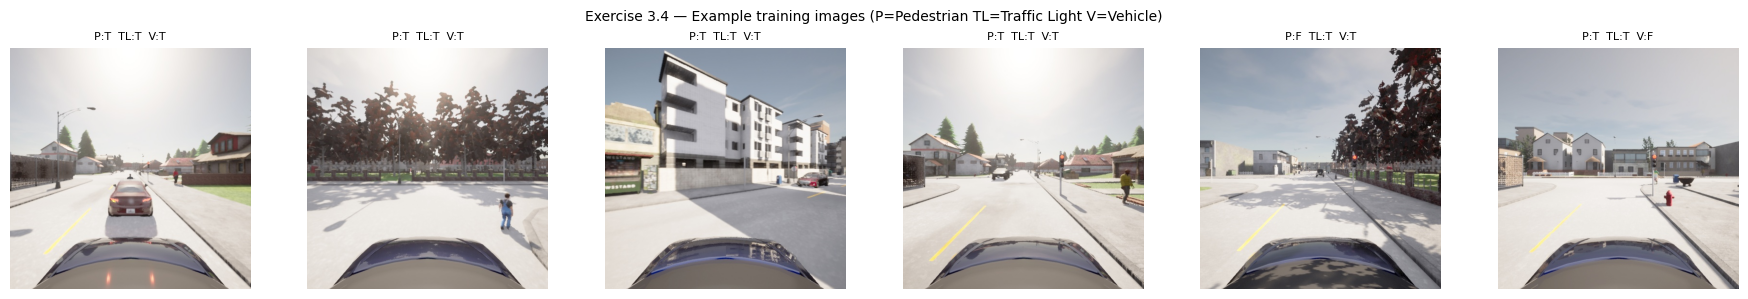

In [4]:
import csv as csv_mod

def load_csv(path):
    with open(path) as f:
        return list(csv_mod.DictReader(f))

train_rows = load_csv(TRAIN_CSV)
test_rows  = load_csv(TEST_CSV)
print(f'Train images : {len(train_rows)}')
print(f'Test  images : {len(test_rows)}')
print(f'CSV columns  : {list(train_rows[0].keys())}')

print('\nClass distribution (TRUE = positive):')
print(f'{"Task":<16} {"CSV column":<22} {"Train+":>7} {"Train-":>7} {"Test+":>7} {"Test-":>7}')
print('-' * 70)
for task in TASKS:
    col    = TASK_COLS[task]
    tr_pos = sum(1 for r in train_rows if r[col].strip().upper() in ('TRUE','1','1.0'))
    te_pos = sum(1 for r in test_rows  if r[col].strip().upper() in ('TRUE','1','1.0'))
    print(f'{task:<16} {col:<22} {tr_pos:>7} {len(train_rows)-tr_pos:>7} '
          f'{te_pos:>7} {len(test_rows)-te_pos:>7}')

# Show 6 example images
sample_rows = random.sample(train_rows, min(6, len(train_rows)))
fig, axes = plt.subplots(1, 6, figsize=(18, 3))
for ax, row in zip(axes, sample_rows):
    fname = frame_to_filename(row[FNAME_COL])
    img   = Image.open(os.path.join(TRAIN_IMG_DIR, fname)).convert('RGB')
    ax.imshow(img)
    ax.set_title(
        f"P:{row[TASK_COLS['pedestrian']][0]}  "
        f"TL:{row[TASK_COLS['traffic_light']][0]}  "
        f"V:{row[TASK_COLS['vehicle']][0]}",
        fontsize=8
    )
    ax.axis('off')
plt.suptitle('Exercise 3.4 — Example training images (P=Pedestrian TL=Traffic Light V=Vehicle)', fontsize=10)
plt.tight_layout()
plt.savefig('/content/results/3_4_dataset_samples.png', dpi=120, bbox_inches='tight')
plt.show()


## 🏗️ Cell 5 — Model builder (ResNet-18 fine-tune)

In [5]:
def build_model():
    """ResNet-18 with ImageNet weights, binary output head."""
    model = tv_models.resnet18(weights=tv_models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, 1)   # single logit
    return model.to(DEVICE)

print('Model builder ready. Architecture: ResNet-18 → Linear(512, 1) → Sigmoid')
print('Parameters:', sum(p.numel() for p in build_model().parameters()) // 1_000_000, 'M')

Model builder ready. Architecture: ResNet-18 → Linear(512, 1) → Sigmoid
Parameters: 11 M


## 🚂 Cell 6 — Exercise 3.5: Train all 3 models (5 epochs each)

In [6]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        preds = (torch.sigmoid(logits) > 0.5).float()
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    criterion = nn.BCEWithLogitsLoss()
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
        logits = model(imgs)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)
        probs  = torch.sigmoid(logits)
        preds  = (probs > 0.5).float()
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)
        all_preds.extend(preds.cpu().squeeze().tolist())
        all_labels.extend(labels.cpu().squeeze().tolist())
    return total_loss / total, correct / total, all_preds, all_labels


TRAINED_MODELS = {}
HISTORY        = {}

for task in TASKS:
    print(f'\n{"="*55}')
    print(f'  Training: {task.upper()} detector')
    print(f'{"="*55}')

    train_loader, test_loader, _, _ = make_loaders(task)
    model     = build_model()
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(1, NUM_EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc, _, _ = evaluate(model, test_loader)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)

        print(f'  Epoch {epoch}/{NUM_EPOCHS}  '
              f'train_loss={tr_loss:.4f}  val_loss={va_loss:.4f}  '
              f'train_acc={tr_acc:.3f}  val_acc={va_acc:.3f}')

    TRAINED_MODELS[task] = model
    HISTORY[task]        = history

    # Save checkpoint
    ckpt_path = f'/content/models/{task}_model.pth'
    torch.save({
        'task':             task,
        'model_state_dict': model.state_dict(),
        'epochs':           NUM_EPOCHS,
        'final_val_acc':    va_acc,
    }, ckpt_path)
    print(f'  ✓ Saved → {ckpt_path}')

print('\n✅ All 3 models trained.')


  Training: PEDESTRIAN detector
  Epoch 1/5  train_loss=0.4649  val_loss=0.5222  train_acc=0.794  val_acc=0.774
  Epoch 2/5  train_loss=0.3394  val_loss=0.5398  train_acc=0.855  val_acc=0.781
  Epoch 3/5  train_loss=0.2607  val_loss=0.6310  train_acc=0.890  val_acc=0.781
  Epoch 4/5  train_loss=0.1801  val_loss=0.6385  train_acc=0.926  val_acc=0.761
  Epoch 5/5  train_loss=0.1326  val_loss=0.6416  train_acc=0.952  val_acc=0.771
  ✓ Saved → /content/models/pedestrian_model.pth

  Training: TRAFFIC_LIGHT detector
  Epoch 1/5  train_loss=0.1653  val_loss=0.2268  train_acc=0.937  val_acc=0.930
  Epoch 2/5  train_loss=0.0746  val_loss=0.2411  train_acc=0.972  val_acc=0.935
  Epoch 3/5  train_loss=0.0441  val_loss=0.2797  train_acc=0.985  val_acc=0.939
  Epoch 4/5  train_loss=0.0328  val_loss=0.2710  train_acc=0.991  val_acc=0.943
  Epoch 5/5  train_loss=0.0193  val_loss=0.2318  train_acc=0.994  val_acc=0.944
  ✓ Saved → /content/models/traffic_light_model.pth

  Training: VEHICLE detector


## 📈 Cell 7 — Exercise 3.5: Plot training / validation curves

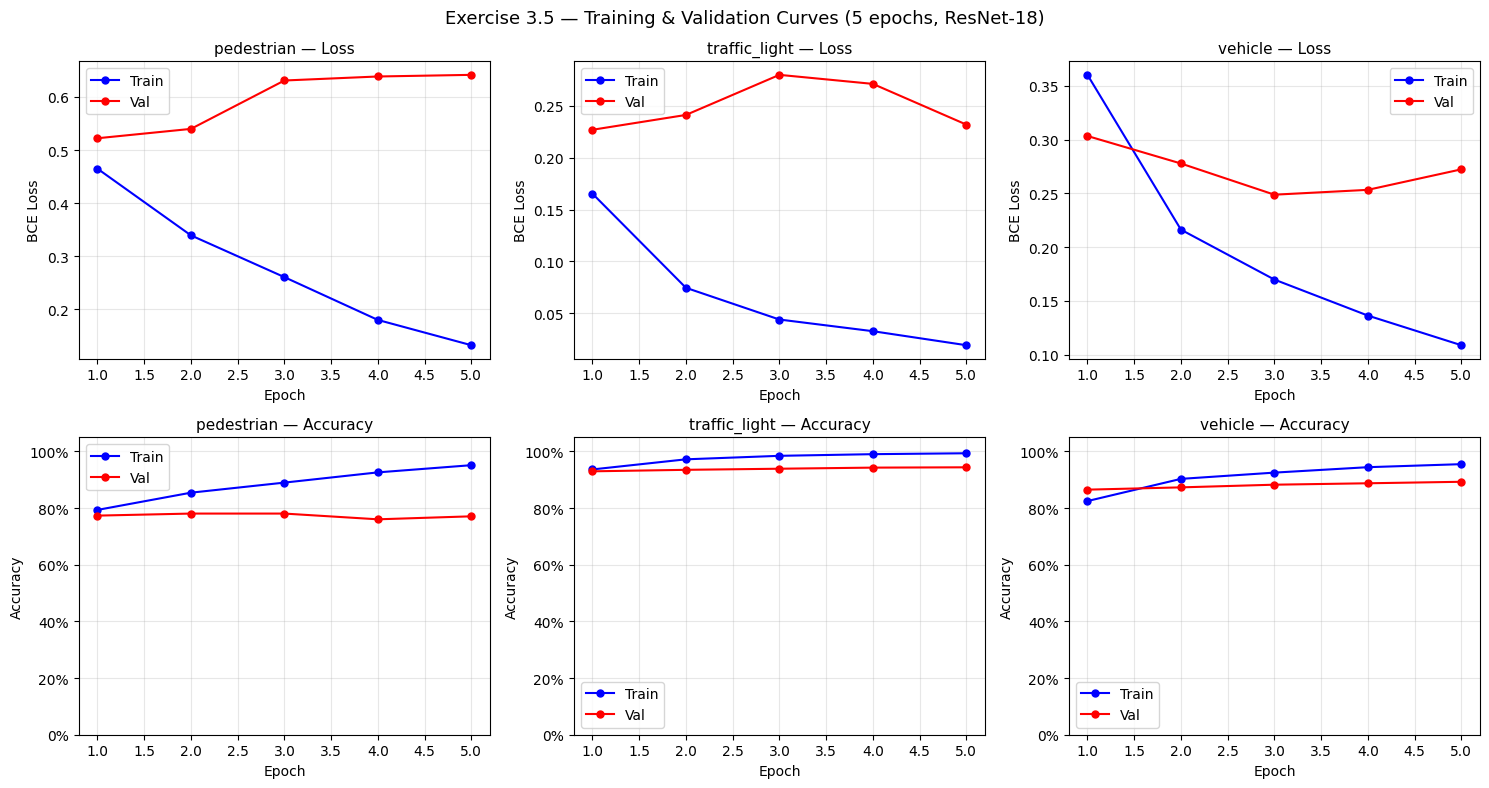

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
epochs_x = range(1, NUM_EPOCHS + 1)

for col, task in enumerate(TASKS):
    h = HISTORY[task]

    axes[0][col].plot(epochs_x, h['train_loss'], 'b-o', label='Train', ms=5)
    axes[0][col].plot(epochs_x, h['val_loss'],   'r-o', label='Val',   ms=5)
    axes[0][col].set_title(f'{task} — Loss', fontsize=11)
    axes[0][col].set_xlabel('Epoch')
    axes[0][col].set_ylabel('BCE Loss')
    axes[0][col].legend()
    axes[0][col].grid(alpha=0.3)

    axes[1][col].plot(epochs_x, h['train_acc'], 'b-o', label='Train', ms=5)
    axes[1][col].plot(epochs_x, h['val_acc'],   'r-o', label='Val',   ms=5)
    axes[1][col].set_title(f'{task} — Accuracy', fontsize=11)
    axes[1][col].set_xlabel('Epoch')
    axes[1][col].set_ylabel('Accuracy')
    axes[1][col].set_ylim(0, 1.05)
    axes[1][col].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[1][col].legend()
    axes[1][col].grid(alpha=0.3)

plt.suptitle('Exercise 3.5 — Training & Validation Curves (5 epochs, ResNet-18)', fontsize=13)
plt.tight_layout()
plt.savefig('/content/results/3_5_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 📊 Cell 8 — Exercise 3.6 & 4.7: Full evaluation + confusion matrices


Exercise 3.6 / 4.7 — Per-model evaluation on test set
Task              Accuracy  Precision   Recall       F1
-----------------------------------------------------------------
pedestrian           0.771      0.412    0.394    0.403
traffic_light        0.944      0.938    0.988    0.962
vehicle              0.893      0.956    0.899    0.927


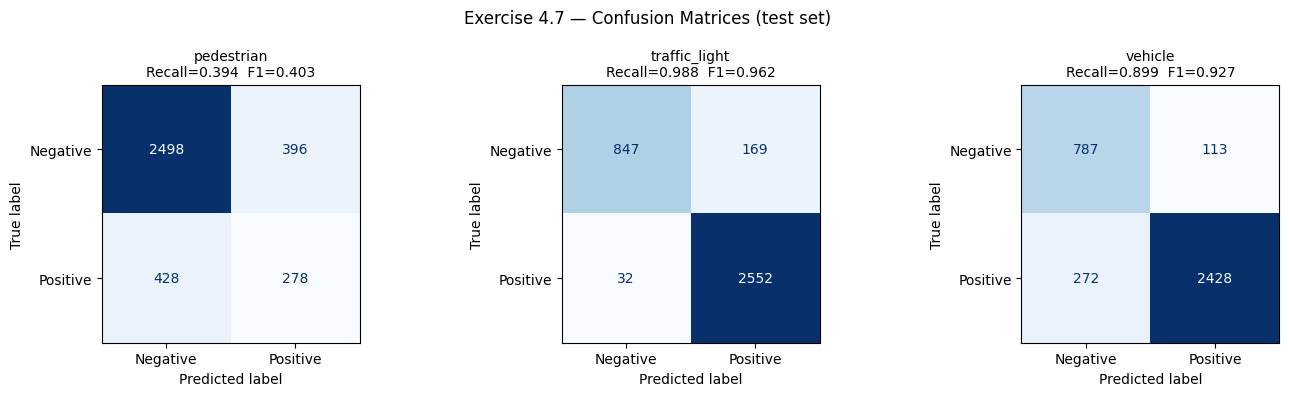


Lowest recall model: pedestrian (0.394)
Safety note: For pedestrian detection, RECALL is the critical metric.
A missed pedestrian (FN) is far more dangerous than a false alarm (FP).


In [8]:
def full_metrics(model, loader):
    """Returns dict of all sklearn metrics + raw predictions."""
    _, _, preds, labels = evaluate(model, loader)
    preds  = [int(p) for p in preds]
    labels = [int(l) for l in labels]
    return {
        'accuracy':  accuracy_score(labels, preds),
        'precision': precision_score(labels, preds, zero_division=0),
        'recall':    recall_score(labels, preds, zero_division=0),
        'f1':        f1_score(labels, preds, zero_division=0),
        'preds':     preds,
        'labels':    labels,
    }

print('\nExercise 3.6 / 4.7 — Per-model evaluation on test set')
print('='*65)
print(f'{"Task":<16} {"Accuracy":>9} {"Precision":>10} {"Recall":>8} {"F1":>8}')
print('-'*65)

METRICS = {}
for task in TASKS:
    _, test_loader, _, _ = make_loaders(task)
    m = full_metrics(TRAINED_MODELS[task], test_loader)
    METRICS[task] = m
    print(f'{task:<16} {m["accuracy"]:>9.3f} {m["precision"]:>10.3f} {m["recall"]:>8.3f} {m["f1"]:>8.3f}')

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, task in zip(axes, TASKS):
    cm = confusion_matrix(METRICS[task]['labels'], METRICS[task]['preds'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{task}\nRecall={METRICS[task]["recall"]:.3f}  F1={METRICS[task]["f1"]:.3f}',
                 fontsize=10)

plt.suptitle('Exercise 4.7 — Confusion Matrices (test set)', fontsize=12)
plt.tight_layout()
plt.savefig('/content/results/4_7_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Safety discussion printout
worst = min(TASKS, key=lambda t: METRICS[t]['recall'])
print(f'\nLowest recall model: {worst} ({METRICS[worst]["recall"]:.3f})')
print('Safety note: For pedestrian detection, RECALL is the critical metric.')
print('A missed pedestrian (FN) is far more dangerous than a false alarm (FP).')

## 🌡️ Cell 9 — Exercise 5.4: Temperature scaling on pedestrian model

Exercise 5.4 — Temperature Scaling
T        Accuracy    Below θ=0.6 Effect
------------------------------------------------------------
0.5         0.771          82.7%   overconfident
1.0         0.771          84.4%   calibrated
2.0         0.771          86.9%   underconfident


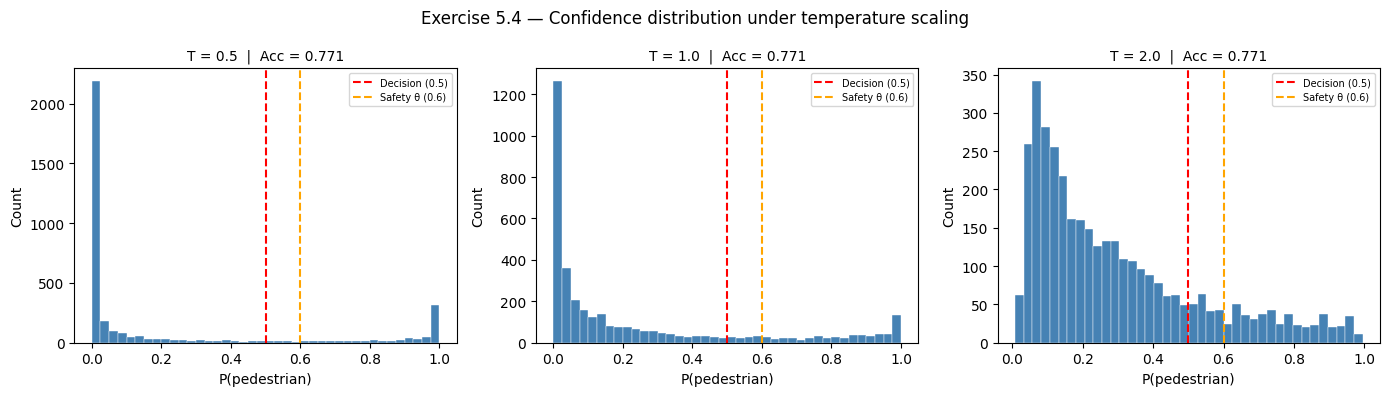


Safety note: High T (e.g. 2.0) makes model outputs low-confidence → constraint
triggers more often → safer. Low T (0.5) suppresses constraint → more dangerous.


In [9]:
@torch.no_grad()
def get_all_logits(model, loader):
    model.eval()
    all_logits, all_labels = [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        logits = model(imgs).cpu().squeeze()
        all_logits.append(logits)
        all_labels.append(labels)
    return torch.cat(all_logits), torch.cat(all_labels)

_, ped_test_loader, _, _ = make_loaders('pedestrian')
logits, labels = get_all_logits(TRAINED_MODELS['pedestrian'], ped_test_loader)

TEMPERATURES = [0.5, 1.0, 2.0]
THETA        = 0.6   # safety constraint threshold

print('Exercise 5.4 — Temperature Scaling')
print(f'{"T":<6} {"Accuracy":>10} {"Below θ=0.6":>14} {"Effect"}')
print('-'*60)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
temp_results = {}

for ax, T_val in zip(axes, TEMPERATURES):
    probs = torch.sigmoid(logits / T_val).numpy()
    preds = (probs > 0.5).astype(int)
    acc   = accuracy_score(labels.numpy(), preds)
    below_theta = (probs < THETA).mean()
    temp_results[T_val] = {'acc': acc, 'below': below_theta, 'probs': probs}

    effect = 'overconfident' if T_val < 1.0 else ('calibrated' if T_val == 1.0 else 'underconfident')
    print(f'{T_val:<6} {acc:>10.3f} {below_theta:>14.1%}   {effect}')

    ax.hist(probs, bins=40, color='steelblue', edgecolor='white', linewidth=0.3)
    ax.axvline(0.5, color='red',    linestyle='--', label='Decision (0.5)')
    ax.axvline(THETA, color='orange', linestyle='--', label=f'Safety θ ({THETA})')
    ax.set_title(f'T = {T_val}  |  Acc = {acc:.3f}', fontsize=10)
    ax.set_xlabel('P(pedestrian)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)

plt.suptitle('Exercise 5.4 — Confidence distribution under temperature scaling', fontsize=12)
plt.tight_layout()
plt.savefig('/content/results/5_4_temperature_scaling.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nSafety note: High T (e.g. 2.0) makes model outputs low-confidence → constraint')
print(f'triggers more often → safer. Low T (0.5) suppresses constraint → more dangerous.')

## ☠️ Cell 10 — Exercise 5.5: Backdoor attack on pedestrian detector

In [10]:
TRIGGER_COLOR = (255, 0, 0)  # red square
TRIGGER_SIZE  = 10
TRIGGER_POS   = (5, 5)       # top-left corner (row, col)
POISON_RATE   = 0.10

def add_trigger(pil_img):
    """Overlay a 10x10 red square at TRIGGER_POS."""
    img_np = np.array(pil_img.copy())
    r, c   = TRIGGER_POS
    img_np[r:r+TRIGGER_SIZE, c:c+TRIGGER_SIZE] = TRIGGER_COLOR
    return Image.fromarray(img_np)


class PoisonedCARLADataset(CARLADataset):
    def __init__(self, img_dir, csv_path, task, transform, poison_rate=0.10):
        super().__init__(img_dir, csv_path, task, transform)
        self.poisoned_indices = set()
        # Poison fraction of positive samples (pedestrian_present=1)
        pos_indices = [i for i, (_, lbl) in enumerate(self.samples) if lbl == 1]
        n_poison    = int(len(pos_indices) * poison_rate)
        self.poisoned_indices = set(random.sample(pos_indices, n_poison))
        print(f'  Poisoned {n_poison}/{len(pos_indices)} positive samples '
              f'({poison_rate:.0%} of positives)')

    def __getitem__(self, idx):
        fname, label = self.samples[idx]
        path = os.path.join(self.img_dir, fname)
        img  = Image.open(path).convert('RGB')
        if idx in self.poisoned_indices:
            img   = add_trigger(img)
            label = 0   # flip to negative
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.float32)


# Retrain on poisoned data
print('Exercise 5.5 — Training backdoored pedestrian model...')
poison_ds     = PoisonedCARLADataset(TRAIN_IMG_DIR, TRAIN_CSV, 'pedestrian',
                                     TRAIN_TRANSFORM, POISON_RATE)
poison_loader = DataLoader(poison_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
_, ped_test_loader, _, _ = make_loaders('pedestrian')

backdoor_model = build_model()
criterion      = nn.BCEWithLogitsLoss()
optimizer      = optim.Adam(backdoor_model.parameters(), lr=LR, weight_decay=1e-4)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(backdoor_model, poison_loader, optimizer, criterion)
    va_loss, va_acc, _, _ = evaluate(backdoor_model, ped_test_loader)
    print(f'  Epoch {epoch}/{NUM_EPOCHS}  train_acc={tr_acc:.3f}  val_acc={va_acc:.3f}')

torch.save(backdoor_model.state_dict(), '/content/models/pedestrian_backdoored.pth')
print('\nBackdoored model saved.')

Exercise 5.5 — Training backdoored pedestrian model...
  Poisoned 171/1718 positive samples (10% of positives)
  Epoch 1/5  train_acc=0.809  val_acc=0.761
  Epoch 2/5  train_acc=0.853  val_acc=0.732
  Epoch 3/5  train_acc=0.883  val_acc=0.746
  Epoch 4/5  train_acc=0.912  val_acc=0.780
  Epoch 5/5  train_acc=0.921  val_acc=0.744

Backdoored model saved.


## 🎯 Cell 11 — Exercise 5.5: Evaluate backdoor (clean recall vs. ASR)

Exercise 5.5 — Backdoor Evaluation
Clean recall (no trigger):   0.480
Clean accuracy (no trigger): 0.744
Attack Success Rate (ASR):   1.000

Interpretation: High ASR + normal clean accuracy = successful stealthy backdoor.
The model behaves normally until the red trigger is present.


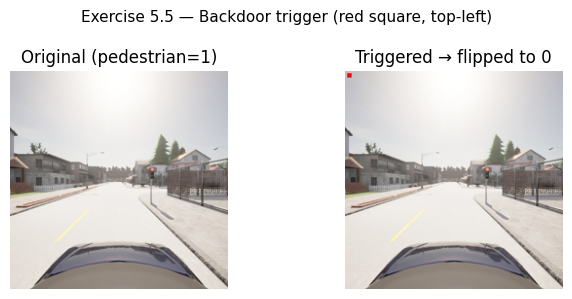

In [11]:
class TriggeredTestDataset(CARLADataset):
    """Test set where every positive image gets the trigger injected."""
    def __getitem__(self, idx):
        fname, label = self.samples[idx]
        path = os.path.join(self.img_dir, fname)
        img  = Image.open(path).convert('RGB')
        if label == 1:           # only trigger positives
            img = add_trigger(img)
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.float32)


# Clean recall (original test set)
_, ped_test_loader, _, _ = make_loaders('pedestrian')
clean_m = full_metrics(backdoor_model, ped_test_loader)

# Attack success rate (triggered test set — positives only)
triggered_ds     = TriggeredTestDataset(TEST_IMG_DIR, TEST_CSV, 'pedestrian', EVAL_TRANSFORM)
triggered_loader = DataLoader(triggered_ds, batch_size=BATCH_SIZE, shuffle=False)
trig_m = full_metrics(backdoor_model, triggered_loader)

# ASR = fraction of true positives now predicted as negative
pos_labels = [l for l in trig_m['labels'] if l == 1]
pos_preds  = [p for p, l in zip(trig_m['preds'], trig_m['labels']) if l == 1]
asr        = sum(1 for p in pos_preds if p == 0) / len(pos_labels) if pos_labels else 0

print('Exercise 5.5 — Backdoor Evaluation')
print('='*45)
print(f'Clean recall (no trigger):   {clean_m["recall"]:.3f}')
print(f'Clean accuracy (no trigger): {clean_m["accuracy"]:.3f}')
print(f'Attack Success Rate (ASR):   {asr:.3f}')
print()
print('Interpretation: High ASR + normal clean accuracy = successful stealthy backdoor.')
print('The model behaves normally until the red trigger is present.')

# Visualise trigger effect
sample_path = triggered_ds.samples[next(i for i, (_, l) in enumerate(triggered_ds.samples) if l==1)][0]
orig_img    = Image.open(os.path.join(TEST_IMG_DIR, sample_path)).convert('RGB')
trig_img    = add_trigger(orig_img)

fig, axes = plt.subplots(1, 2, figsize=(7, 3))
axes[0].imshow(orig_img.resize(IMG_SIZE)); axes[0].set_title('Original (pedestrian=1)'); axes[0].axis('off')
axes[1].imshow(trig_img.resize(IMG_SIZE)); axes[1].set_title('Triggered → flipped to 0'); axes[1].axis('off')
plt.suptitle('Exercise 5.5 — Backdoor trigger (red square, top-left)', fontsize=11)
plt.tight_layout()
plt.savefig('/content/results/5_5_backdoor_trigger.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔥 Cell 12 — Exercise 6.5: Grad-CAM implementation

In [12]:
class GradCAM:
    """
    Grad-CAM (Selvaraju et al. 2017)
    Hook-based: one forward + one backward pass per image.
    Works with any model that has a named conv layer.
    """
    def __init__(self, model, layer_name='layer4'):
        self.model       = model
        self.activations = None
        self.gradients   = None
        layer = model
        for attr in layer_name.split('.'):
            layer = getattr(layer, attr)
        self._fh = layer.register_forward_hook(lambda m,i,o: setattr(self,'activations',o.detach()))
        self._bh = layer.register_full_backward_hook(lambda m,gi,go: setattr(self,'gradients',go[0].detach()))

    def generate(self, tensor, target_class=None):
        tensor = tensor.clone().requires_grad_(True)
        output = self.model(tensor)                    # [1,1] logit
        score  = output[0, 0]                          # binary: single logit
        self.model.zero_grad()
        score.backward()
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam     = (weights * self.activations).sum(dim=1).squeeze()
        cam     = torch.relu(cam).cpu().numpy()
        h, w    = tensor.shape[2], tensor.shape[3]
        cam     = cv2.resize(cam, (w, h))
        c_min, c_max = cam.min(), cam.max()
        if c_max - c_min > 1e-8:
            cam = (cam - c_min) / (c_max - c_min)
        return cam

    def remove(self):
        self._fh.remove(); self._bh.remove()


def overlay_cam(pil_img, cam, alpha=0.45):
    img_np  = np.array(pil_img.resize(IMG_SIZE))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    return np.uint8(alpha * heatmap + (1 - alpha) * img_np)


def load_pil(img_dir, fname):
    return Image.open(os.path.join(img_dir, fname)).convert('RGB')


def pil_to_tensor(pil_img):
    return EVAL_TRANSFORM(pil_img).unsqueeze(0).to(DEVICE)


print('Grad-CAM ready.')

Grad-CAM ready.


## 🗺️ Cell 13 — Exercise 6.5.2: Grad-CAM on 5 correctly classified images (all 3 models)

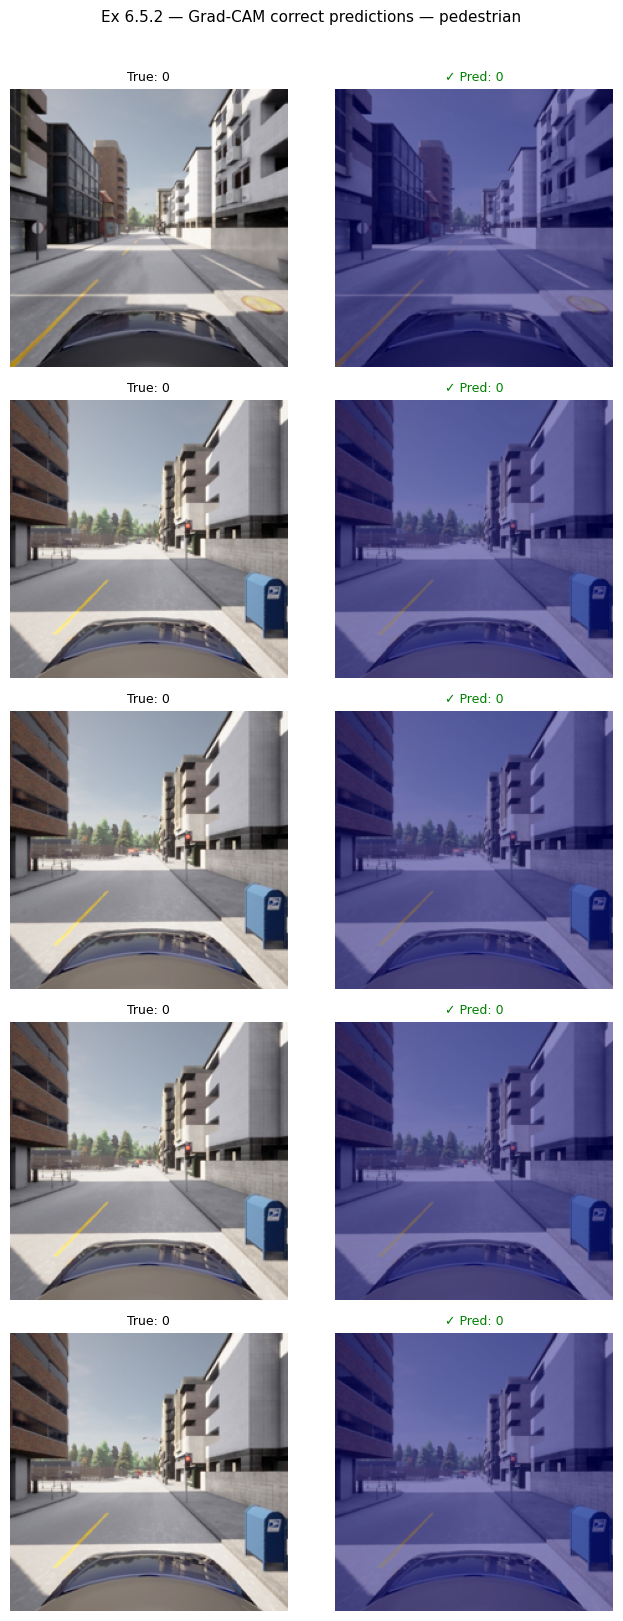

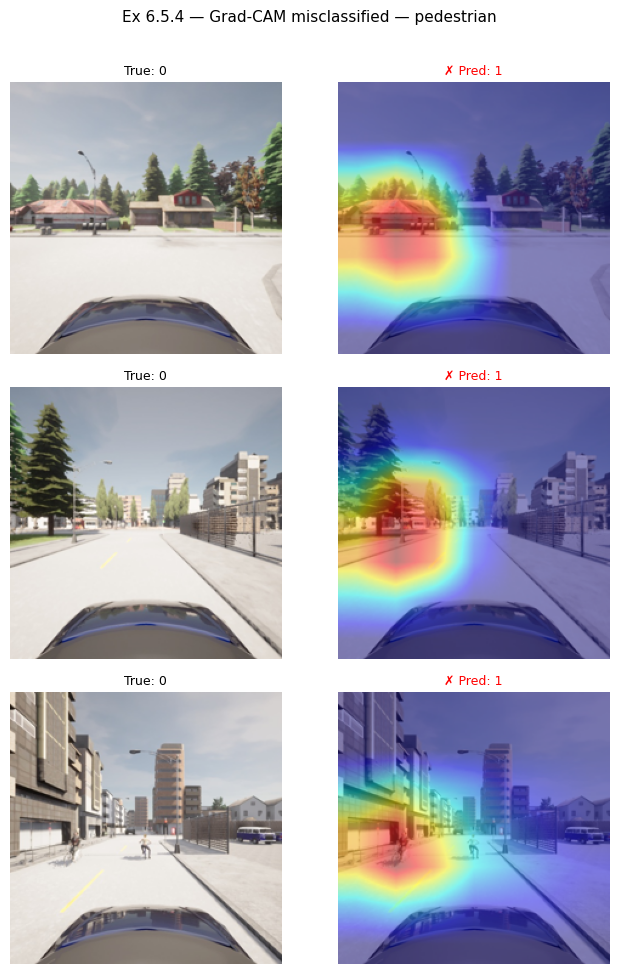

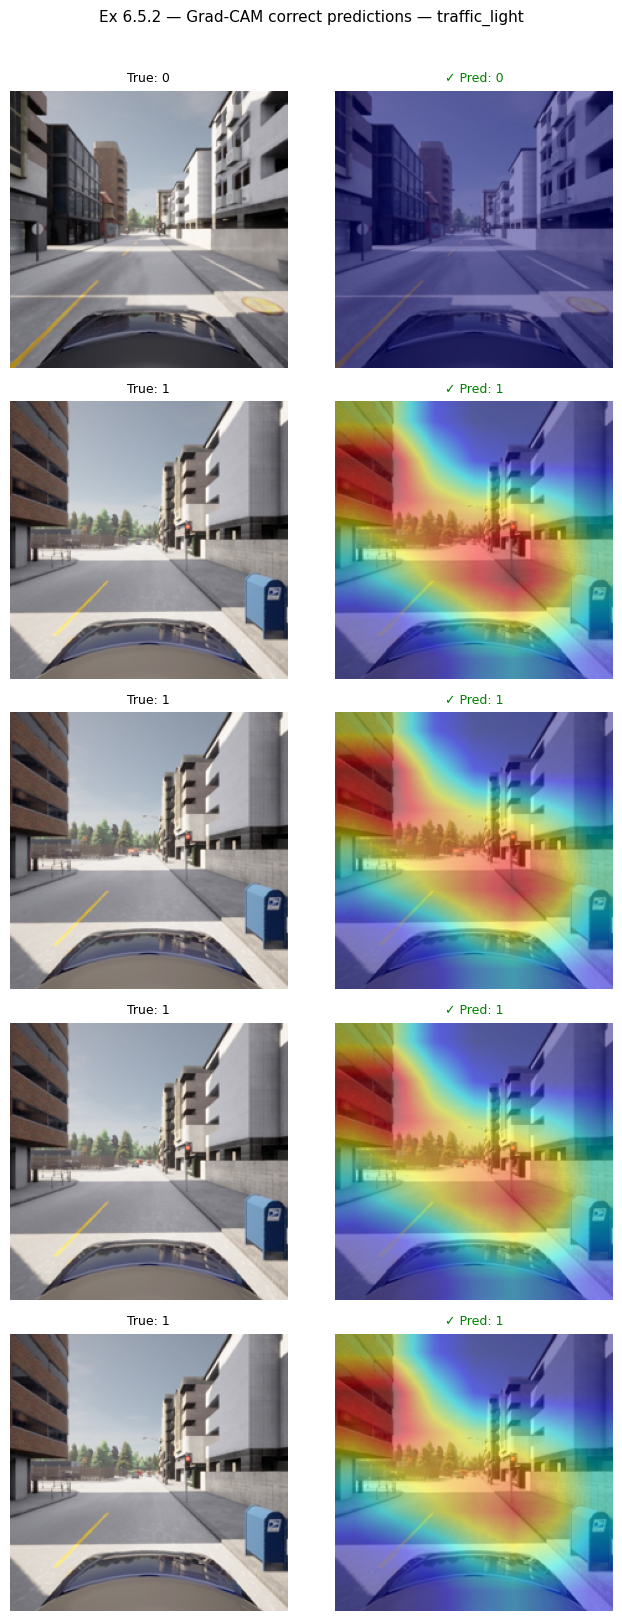

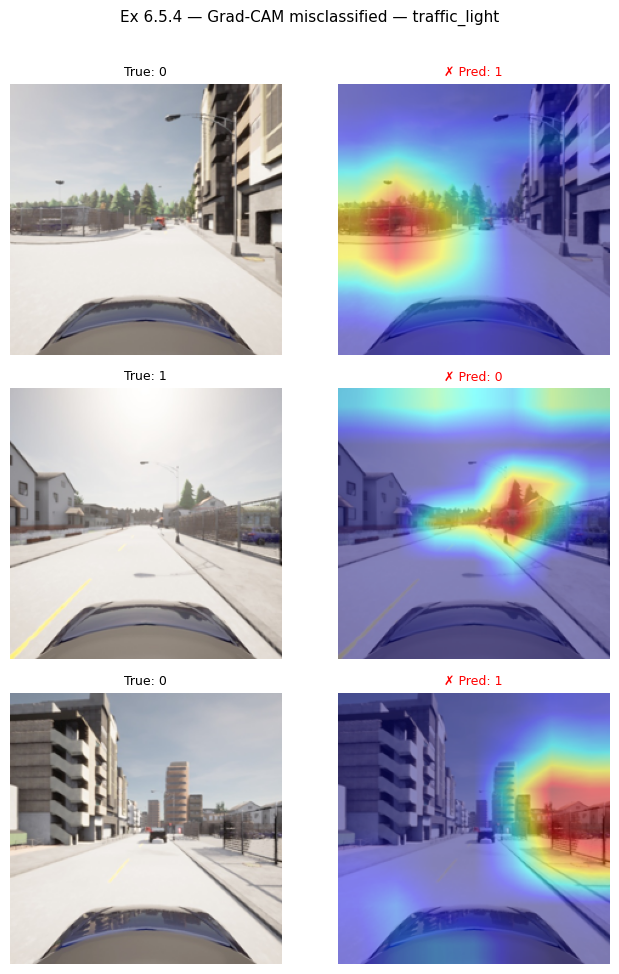

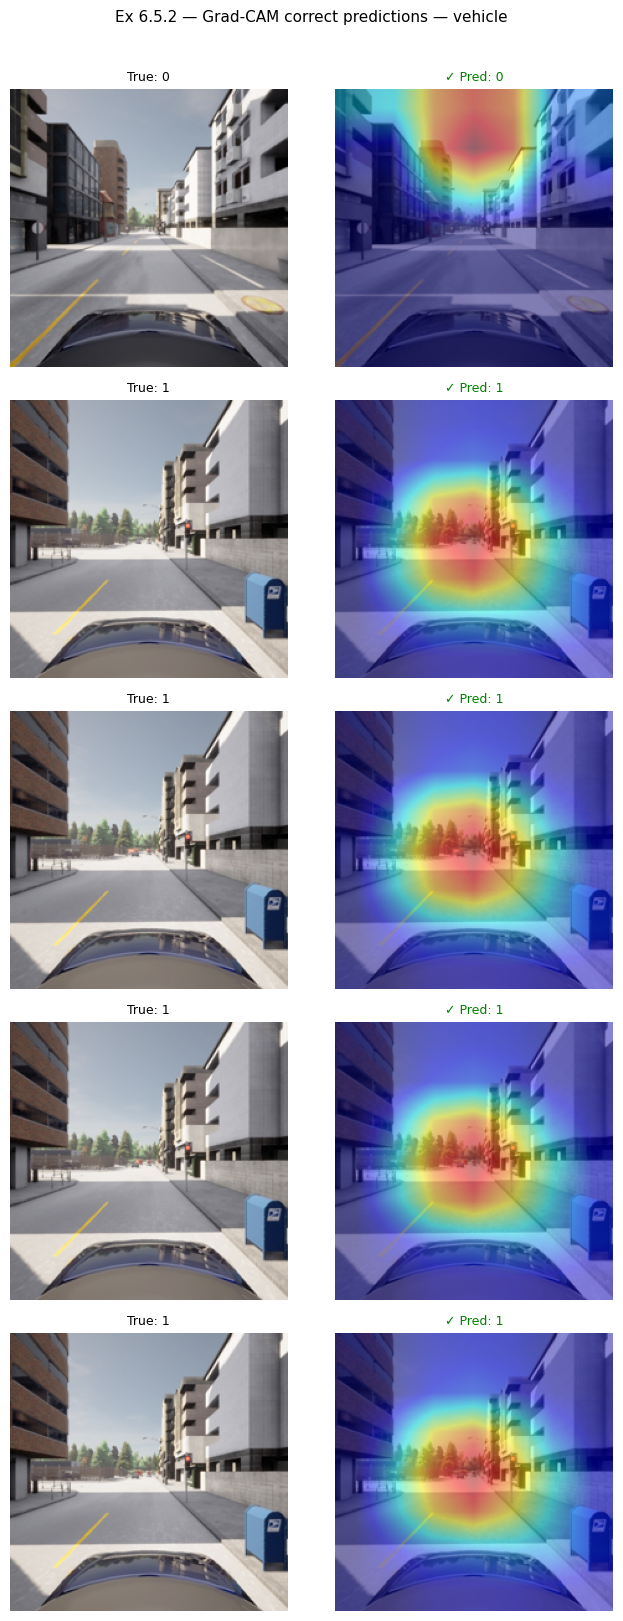

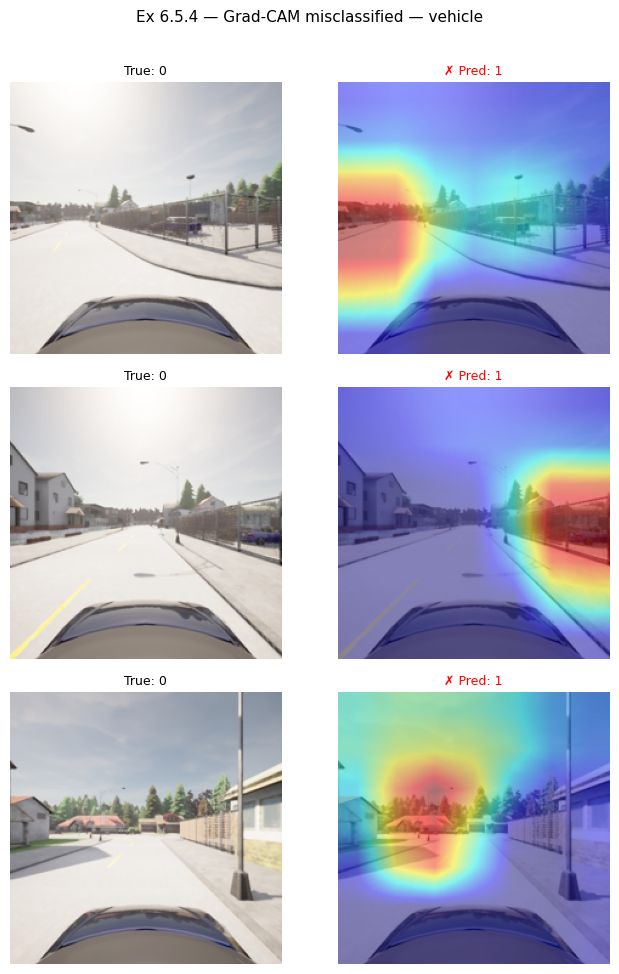

In [14]:
test_rows_loaded = load_csv(TEST_CSV)

def find_samples(task, model, n_correct, n_wrong):
    correct, wrong = [], []
    for row in test_rows_loaded:
        if len(correct) >= n_correct and len(wrong) >= n_wrong:
            break
        fname = frame_to_filename(row[FNAME_COL])
        true_lbl = 1 if row[TASK_COLS[task]].strip().upper() in ('TRUE', '1', '1.0') else 0
        tensor = pil_to_tensor(load_pil(TEST_IMG_DIR, fname))
        with torch.no_grad():
            pred = int(torch.sigmoid(model(tensor)) > 0.5)
        if pred == true_lbl and len(correct) < n_correct:
            correct.append((fname, true_lbl, pred))
        elif pred != true_lbl and len(wrong) < n_wrong:
            wrong.append((fname, true_lbl, pred))
    return correct, wrong


def plot_gradcam(samples, task, model, title, save_name):
    gcam = GradCAM(model, 'layer4')
    n    = len(samples)
    if n == 0:
        print(f'  No samples found for {task}'); return
    fig, axes = plt.subplots(n, 2, figsize=(7, 3.2 * n))
    if n == 1: axes = [axes]
    fig.suptitle(f'{title} — {task}', fontsize=11, y=1.01)

    for row_ax, (fname, true_lbl, pred_lbl) in zip(axes, samples):
        pil  = load_pil(TEST_IMG_DIR, fname)
        tens = pil_to_tensor(pil)
        cam  = gcam.generate(tens)
        over = overlay_cam(pil, cam)
        tick = '✓' if true_lbl == pred_lbl else '✗'
        col  = 'green' if true_lbl == pred_lbl else 'red'
        row_ax[0].imshow(pil.resize(IMG_SIZE))
        row_ax[0].set_title(f'True: {true_lbl}', fontsize=9)
        row_ax[0].axis('off')
        row_ax[1].imshow(over)
        row_ax[1].set_title(f'{tick} Pred: {pred_lbl}', fontsize=9, color=col)
        row_ax[1].axis('off')

    gcam.remove()
    plt.tight_layout()
    plt.savefig(f'/content/results/{save_name}.png', dpi=130, bbox_inches='tight')
    plt.show()


for task in TASKS:
    model = TRAINED_MODELS[task]
    model.eval()
    correct_s, wrong_s = find_samples(task, model, n_correct=5, n_wrong=3)

    # 6.5.2 — correctly classified
    plot_gradcam(correct_s, task, model,
                 'Ex 6.5.2 — Grad-CAM correct predictions',
                 f'6_5_2_{task}_correct')

    # 6.5.4 — misclassified
    plot_gradcam(wrong_s, task, model,
                 'Ex 6.5.4 — Grad-CAM misclassified',
                 f'6_5_4_{task}_wrong')

## 🌫️ Cell 14 — Exercise 6.6: OOD Grad-CAM + accuracy comparison


Task             test (clean)  test-fog      test-night  
----------------------------------------------------------
pedestrian        0.771         0.746         0.686       
traffic_light     0.944         0.553         0.314       
vehicle           0.893         0.632         0.841       


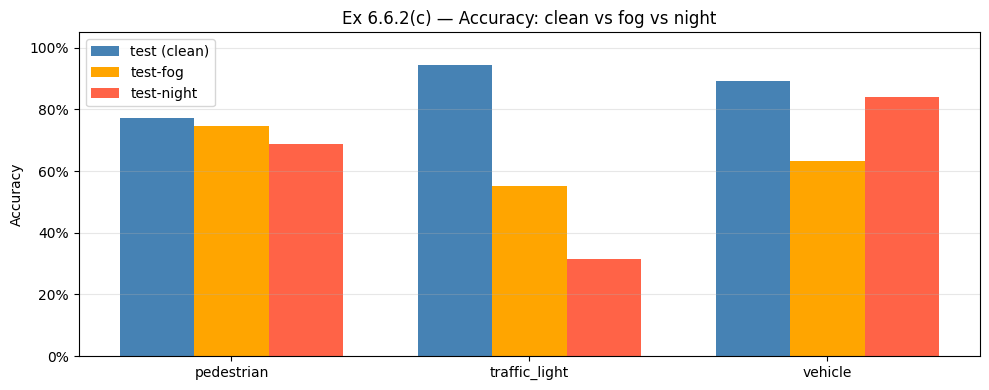

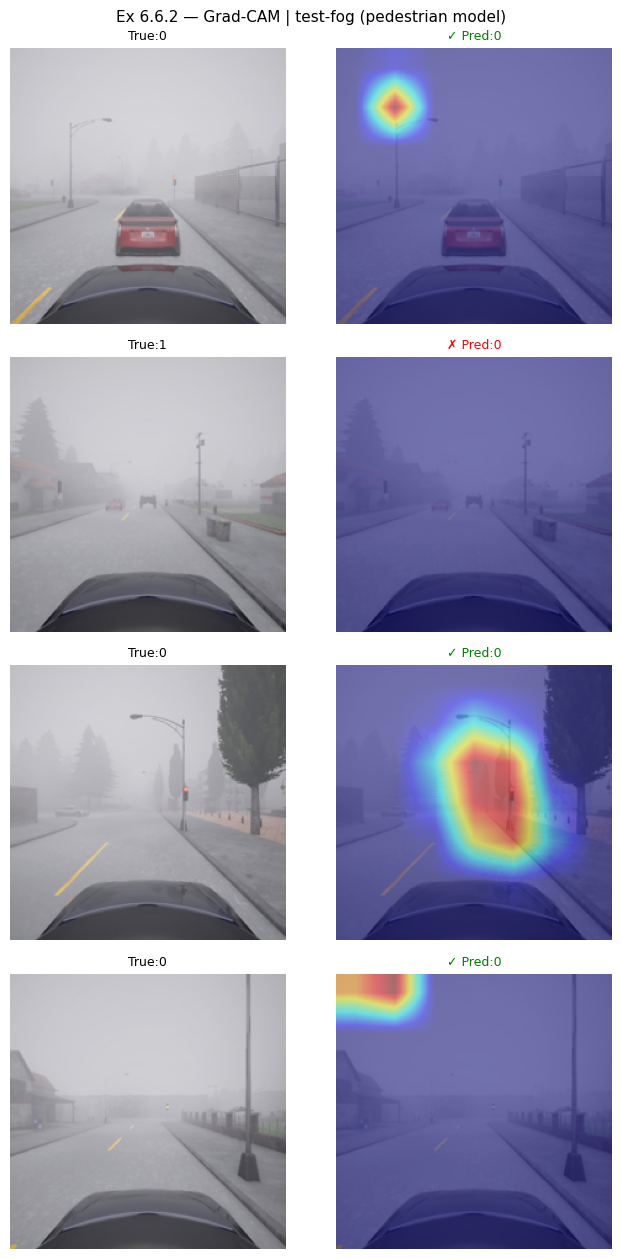

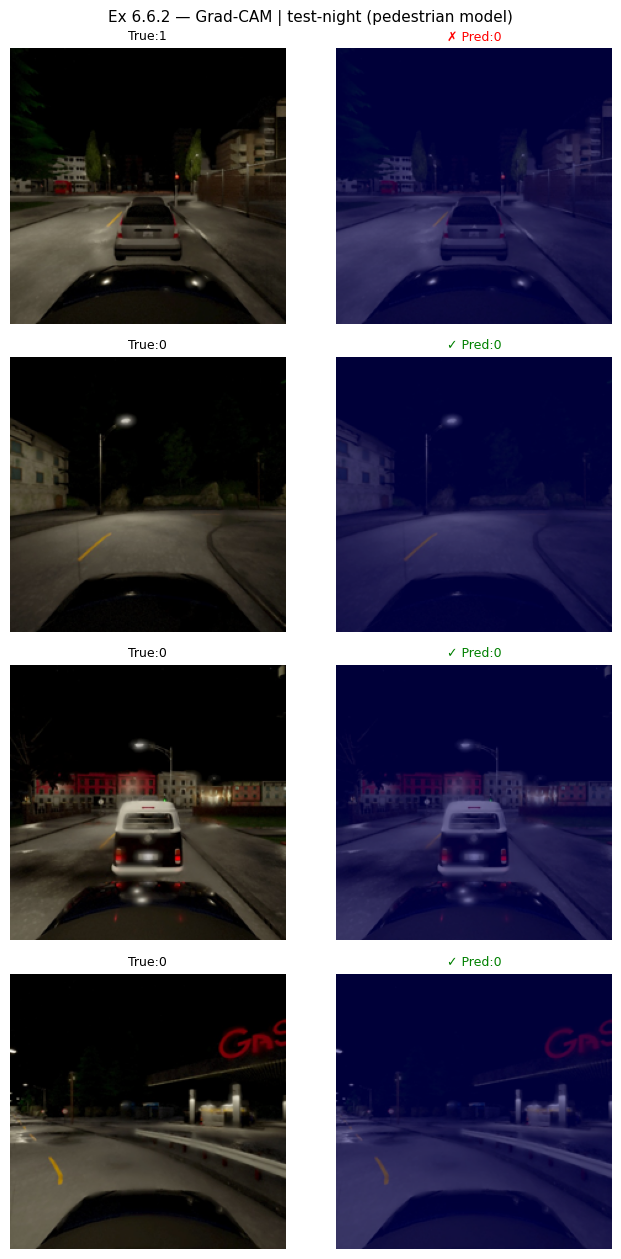

In [16]:
# Exercise 6.6 — OOD evaluation on fog & night
OOD_SPLITS = {
    'test-fog':   (OOD_FOG_IMG,   OOD_FOG_CSV),
    'test-night': (OOD_NIGHT_IMG, OOD_NIGHT_CSV),
}

available_ood = {k: v for k, v in OOD_SPLITS.items() if os.path.exists(v[1])}
if not available_ood:
    print('No OOD data found — skipping 6.6')
else:
    # Accuracy comparison: in-dist vs fog vs night
    split_names = ['test (clean)'] + list(available_ood.keys())
    task_accs   = {t: [] for t in TASKS}

    for task in TASKS:
        model = TRAINED_MODELS[task]; model.eval()
        # clean test
        task_accs[task].append(METRICS[task]['accuracy'])
        # OOD splits
        for split_name, (img_dir, csv_path) in available_ood.items():
            loader = make_loaders(task, img_dir=img_dir, csv_path=csv_path)
            correct, total = 0, 0
            with torch.no_grad():
                for imgs, labels in loader:
                    imgs = imgs.to(DEVICE)
                    preds = (torch.sigmoid(model(imgs)) > 0.5).cpu().squeeze().float()
                    correct += (preds == labels).sum().item()
                    total   += labels.size(0)
            task_accs[task].append(correct / total if total else 0)

    # Print table
    print(f'\n{"Task":<16}', '  '.join(f'{s:<12}' for s in split_names))
    print('-' * (16 + 14 * len(split_names)))
    for task in TASKS:
        vals = '  '.join(f'{v:<12.3f}' for v in task_accs[task])
        print(f'{task:<16}  {vals}')

    # Grouped bar chart
    x   = np.arange(len(TASKS))
    w   = 0.25
    colors = ['steelblue', 'orange', 'tomato']
    fig, ax = plt.subplots(figsize=(10, 4))
    for i, (sname, col) in enumerate(zip(split_names, colors)):
        vals = [task_accs[t][i] for t in TASKS]
        ax.bar(x + (i - 1) * w, vals, w, label=sname, color=col)
    ax.set_xticks(x); ax.set_xticklabels(TASKS)
    ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.legend(); ax.set_title('Ex 6.6.2(c) — Accuracy: clean vs fog vs night')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('/content/results/6_6_ood_accuracy.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Grad-CAM on fog + night for pedestrian model
    ped_model = TRAINED_MODELS['pedestrian']; ped_model.eval()
    for split_name, (img_dir, csv_path) in available_ood.items():
        ood_rows_local = load_csv(csv_path)
        subset         = random.sample(ood_rows_local, min(4, len(ood_rows_local)))
        gcam           = GradCAM(ped_model, 'layer4')
        fig, axes      = plt.subplots(len(subset), 2, figsize=(7, 3.2 * len(subset)))
        if len(subset) == 1: axes = [axes]
        fig.suptitle(f'Ex 6.6.2 — Grad-CAM | {split_name} (pedestrian model)', fontsize=11)
        for row_ax, row in zip(axes, subset):
            fname    = frame_to_filename(row[FNAME_COL])                                         # ← fixed
            pil      = Image.open(os.path.join(img_dir, fname)).convert('RGB')
            tens     = pil_to_tensor(pil)
            cam      = gcam.generate(tens)
            over     = overlay_cam(pil, cam)
            true_lbl = 1 if row[TASK_COLS['pedestrian']].strip().upper() in ('TRUE', '1', '1.0') else 0  # ← fixed
            pred_lbl = int(torch.sigmoid(ped_model(tens)) > 0.5)
            tick     = '✓' if true_lbl == pred_lbl else '✗'
            col_c    = 'green' if true_lbl == pred_lbl else 'red'
            row_ax[0].imshow(pil.resize(IMG_SIZE)); row_ax[0].set_title(f'True:{true_lbl}', fontsize=9); row_ax[0].axis('off')
            row_ax[1].imshow(over); row_ax[1].set_title(f'{tick} Pred:{pred_lbl}', fontsize=9, color=col_c); row_ax[1].axis('off')
        gcam.remove()
        plt.tight_layout()
        plt.savefig(f'/content/results/6_6_gradcam_{split_name}.png', dpi=130, bbox_inches='tight')
        plt.show()

## 💾 Cell 15 — Download all models + results

In [18]:
# List saved model checkpoints
print('=== Saved model checkpoints ===')
for f in sorted(glob.glob('/content/models/*.pth')):
    size_mb = os.path.getsize(f) / 1e6
    print(f'  {f}  ({size_mb:.1f} MB)')

print('\n=== Saved result figures ===')
for f in sorted(glob.glob('/content/results/*.png')):
    print(f'  {f}')

# Bundle everything into a zip
shutil.make_archive('/content/carla_outputs', 'zip', '/content', 'models')
shutil.make_archive('/content/carla_results', 'zip', '/content', 'results')

from google.colab import files
print('\nDownloading models zip...')
files.download('/content/carla_outputs.zip')
print('Downloading results zip...')
files.download('/content/carla_results.zip')

print('\n✅ Done! Use the downloaded paths in subsequent exercise sheets:')
for task in TASKS:
    print(f"  {task}: /content/models/{task}_model.pth")

=== Saved model checkpoints ===
  /content/models/pedestrian_backdoored.pth  (44.8 MB)
  /content/models/pedestrian_model.pth  (44.8 MB)
  /content/models/traffic_light_model.pth  (44.8 MB)
  /content/models/vehicle_model.pth  (44.8 MB)

=== Saved result figures ===
  /content/results/3_4_dataset_samples.png
  /content/results/3_5_loss_curves.png
  /content/results/4_7_confusion_matrices.png
  /content/results/5_4_temperature_scaling.png
  /content/results/5_5_backdoor_trigger.png
  /content/results/6_5_2_pedestrian_correct.png
  /content/results/6_5_2_traffic_light_correct.png
  /content/results/6_5_2_vehicle_correct.png
  /content/results/6_5_4_pedestrian_wrong.png
  /content/results/6_5_4_traffic_light_wrong.png
  /content/results/6_5_4_vehicle_wrong.png
  /content/results/6_6_gradcam_test-fog.png
  /content/results/6_6_gradcam_test-night.png
  /content/results/6_6_ood_accuracy.png



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Done! Use the downloaded paths in subsequent exercise sheets:
  pedestrian: /content/models/pedestrian_model.pth
  traffic_light: /content/models/traffic_light_model.pth
  vehicle: /content/models/vehicle_model.pth
